# Notebook 05 — Reportes Automáticos y Despliegue
Fase 6 CRISP-DM: Deployment
Output: reports/ con reportes completos del IRA Municipal

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pyarrow.parquet as pq
import warnings
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.2f}'.format)

PRIMARY  = Path('../data/03_primary')
OUTPUT   = Path('../data/04_model_output')
REPORTS  = Path('../reports')
FIGURES  = REPORTS / 'figures'
REPORTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# Cargar todos los datos finales
df_ira      = pd.read_parquet(OUTPUT / 'ira_municipal_final.parquet')
df_hist     = pd.read_parquet(OUTPUT / 'ira_historico.parquet')
df_timeline = pd.read_parquet(OUTPUT / 'ira_timeline_completo.parquet')
df_alertas  = pd.read_parquet(OUTPUT / 'alertas_municipios.parquet')
df_cultivos = pd.read_parquet(OUTPUT / 'cultivos_proyeccion_2029.parquet')
df_frontera = pd.read_parquet(OUTPUT / 'municipios_frontera.parquet')
df_criticos = pd.read_parquet(OUTPUT / 'municipios_criticos_intervencion.parquet')
df_lisa     = pd.read_parquet(OUTPUT / 'lisa_clusters.parquet')
df_master   = pd.read_parquet(PRIMARY / 'municipio_features.parquet')

print(f'✅ Datos cargados:')
print(f'   IRA final:      {len(df_ira):,} municipios')
print(f'   IRA histórico:  {len(df_hist):,} registros')
print(f'   Timeline:       {len(df_timeline):,} registros')
print(f'   Alertas:        {len(df_alertas):,} municipios')
print(f'   Cultivos:       {len(df_cultivos):,} registros')
print(f'   LISA clusters:  {len(df_lisa):,} municipios')
print(f'\nFecha del reporte: {datetime.now().strftime("%Y-%m-%d %H:%M")}')

✅ Datos cargados:
   IRA final:      1,122 municipios
   IRA histórico:  4,488 registros
   Timeline:       21,318 registros
   Alertas:        591 municipios
   Cultivos:       3,046 registros
   LISA clusters:  1,121 municipios

Fecha del reporte: 2026-07-23 00:59


REPORTE 1 — Resumen Ejecutivo Nacional


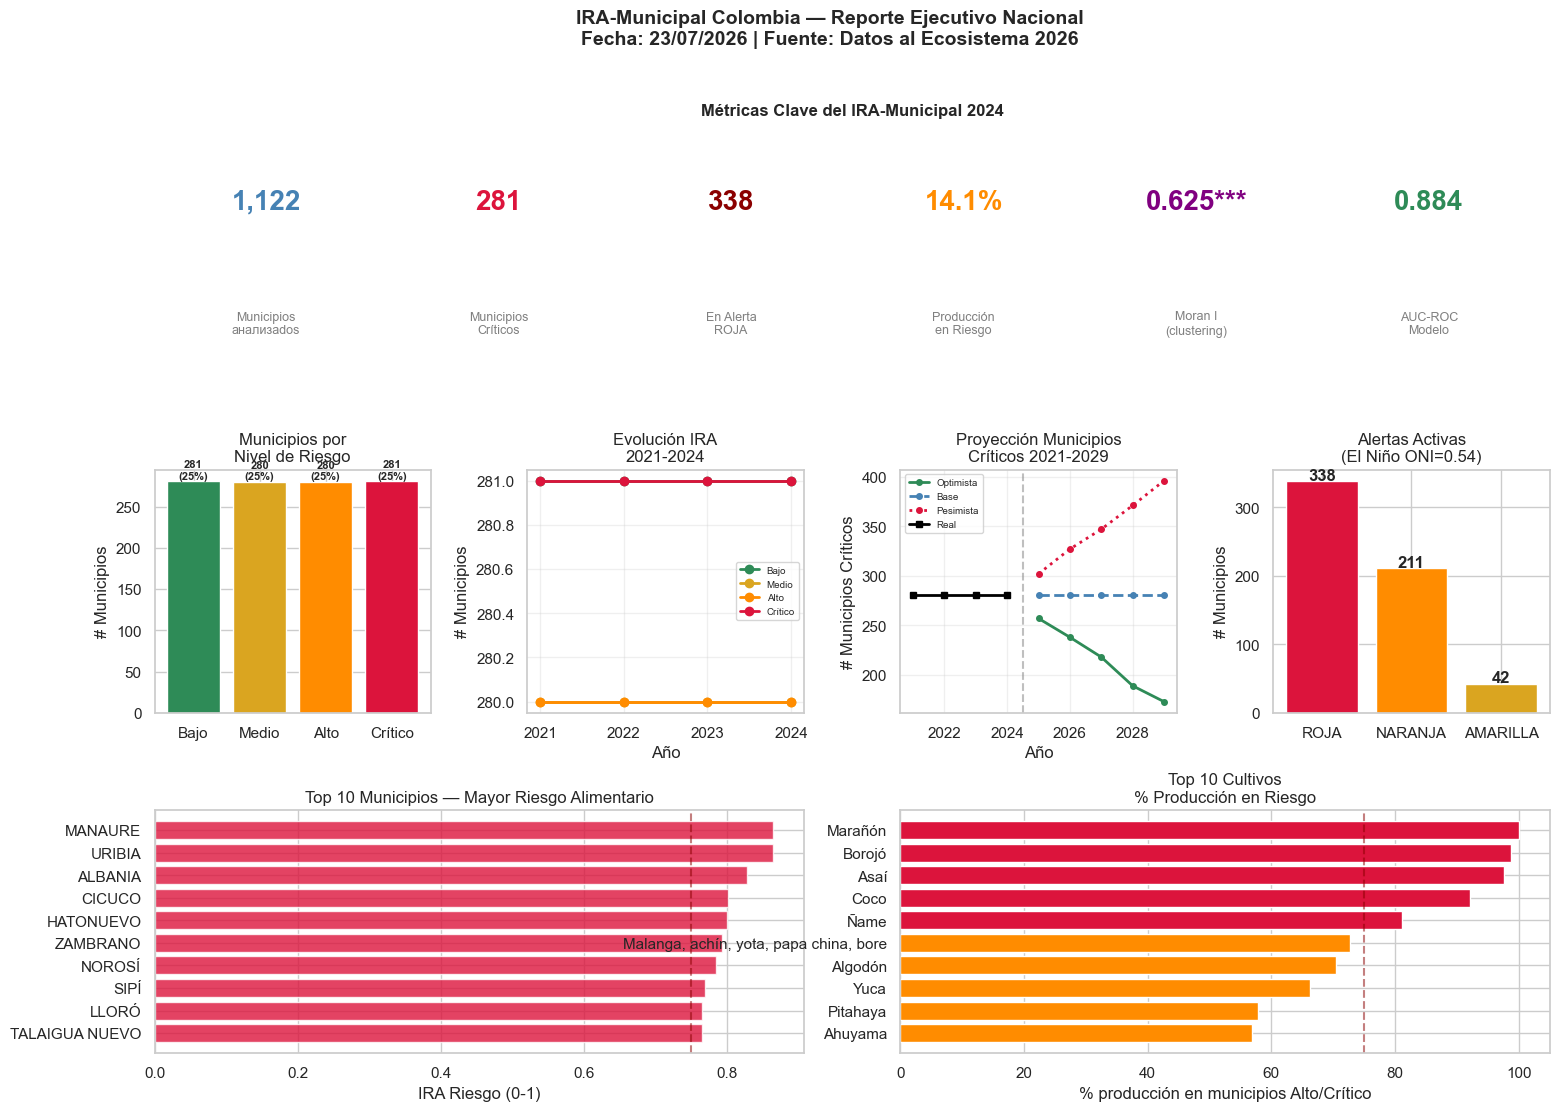

💾 Guardado: reports/figures/reporte_ejecutivo_nacional.png


In [2]:
print('='*60)
print('REPORTE 1 — Resumen Ejecutivo Nacional')
print('='*60)

# Estadísticas nacionales
total_mpio = len(df_ira)
dist_nivel = df_ira['nivel_ira'].value_counts()
dist_alerta = df_alertas['nivel_alerta'].value_counts() if 'nivel_alerta' in df_alertas.columns else {}

# Producción en riesgo
df_cult_2024 = df_cultivos[
    (df_cultivos['anio']==2024) &
    (df_cultivos['escenario']=='Real')
]
prod_nacional = df_cult_2024['produccion_ton'].sum()
prod_riesgo   = df_cult_2024['produccion_riesgo_ton'].sum()
pct_riesgo    = prod_riesgo / prod_nacional * 100

fig = plt.figure(figsize=(18, 12))
fig.suptitle(f'IRA-Municipal Colombia — Reporte Ejecutivo Nacional\n'
             f'Fecha: {datetime.now().strftime("%d/%m/%Y")} | '
             f'Fuente: Datos al Ecosistema 2026',
             fontsize=14, fontweight='bold')

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.4, wspace=0.35)

# ─── Métricas clave ───────────────────────────────────────────────────────────
ax_metricas = fig.add_subplot(gs[0, :])
ax_metricas.axis('off')

metricas = [
    ('Municipios\nанализados', f'{total_mpio:,}', 'steelblue'),
    ('Municipios\nCríticos', f'{dist_nivel.get("Crítico",0):,}', 'crimson'),
    ('En Alerta\nROJA', f'{len(df_alertas[df_alertas["nivel_alerta"]=="ROJA"]) if "nivel_alerta" in df_alertas.columns else "N/A"}', 'darkred'),
    ('Producción\nen Riesgo', f'{pct_riesgo:.1f}%', 'darkorange'),
    ('Moran I\n(clustering)', f'0.625***', 'purple'),
    ('AUC-ROC\nModelo', f'0.884', 'seagreen'),
]

for i, (label, valor, color) in enumerate(metricas):
    x = i / len(metricas)
    ax_metricas.text(x + 0.08, 0.7, valor, ha='center', va='center',
                     fontsize=20, fontweight='bold', color=color,
                     transform=ax_metricas.transAxes)
    ax_metricas.text(x + 0.08, 0.2, label, ha='center', va='center',
                     fontsize=9, color='gray',
                     transform=ax_metricas.transAxes)

ax_metricas.set_title('Métricas Clave del IRA-Municipal 2024',
                       fontsize=12, fontweight='bold', pad=10)

# ─── Distribución por nivel ───────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1, 0])
niveles = ['Bajo','Medio','Alto','Crítico']
conteos = [dist_nivel.get(n, 0) for n in niveles]
colores = ['seagreen','goldenrod','darkorange','crimson']
bars = ax1.bar(niveles, conteos, color=colores, edgecolor='white')
ax1.set_title('Municipios por\nNivel de Riesgo')
ax1.set_ylabel('# Municipios')
for bar, val in zip(bars, conteos):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 3,
             f'{val}\n({val/total_mpio*100:.0f}%)',
             ha='center', fontsize=8, fontweight='bold')

# ─── Evolución histórica ──────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 1])
df_hist_dist = df_hist.groupby(['anio','nivel_ira']).size().unstack(fill_value=0)
for nivel, color in zip(niveles, colores):
    if nivel in df_hist_dist.columns:
        ax2.plot(df_hist_dist.index, df_hist_dist[nivel],
                 color=color, marker='o', linewidth=2, label=nivel)
ax2.set_title('Evolución IRA\n2021-2024')
ax2.set_xlabel('Año')
ax2.set_ylabel('# Municipios')
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

# ─── Proyección escenarios ────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
for escenario, color, estilo in [
    ('Optimista', 'seagreen', '-'),
    ('Base',      'steelblue','--'),
    ('Pesimista', 'crimson',  ':'),
]:
    df_esc = df_timeline[df_timeline['escenario']==escenario]
    dist_esc = df_esc.groupby('anio')['nivel_ira'].apply(
        lambda x: (x=='Crítico').sum()
    )
    ax3.plot(dist_esc.index, dist_esc.values,
             color=color, linestyle=estilo,
             linewidth=2, marker='o', markersize=4,
             label=escenario)

# Añadir histórico
hist_critico = df_hist.groupby('anio').apply(
    lambda x: (x['nivel_ira']=='Crítico').sum()
)
ax3.plot(hist_critico.index, hist_critico.values,
         color='black', linewidth=2, marker='s',
         markersize=5, label='Real')
ax3.axvline(2024.5, color='gray', linestyle='--', alpha=0.5)
ax3.set_title('Proyección Municipios\nCríticos 2021-2029')
ax3.set_xlabel('Año')
ax3.set_ylabel('# Municipios Críticos')
ax3.legend(fontsize=7)
ax3.grid(True, alpha=0.3)

# ─── Alertas activas ─────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 3])
if 'nivel_alerta' in df_alertas.columns:
    niveles_alerta = ['ROJA','NARANJA','AMARILLA']
    conteos_alerta = [
        len(df_alertas[df_alertas['nivel_alerta']==n])
        for n in niveles_alerta
    ]
    colores_alerta = ['crimson','darkorange','goldenrod']
    bars_a = ax4.bar(niveles_alerta, conteos_alerta,
                     color=colores_alerta, edgecolor='white')
    ax4.set_title(f'Alertas Activas\n(El Niño ONI=0.54)')
    ax4.set_ylabel('# Municipios')
    for bar, val in zip(bars_a, conteos_alerta):
        ax4.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2,
                 str(val), ha='center', fontweight='bold')

# ─── Top 10 municipios críticos ───────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
top10 = df_ira.nlargest(10, 'ira_riesgo')
ax5.barh(top10['municipio'][::-1], top10['ira_riesgo'][::-1],
         color='crimson', edgecolor='white', alpha=0.8)
ax5.set_title('Top 10 Municipios — Mayor Riesgo Alimentario')
ax5.set_xlabel('IRA Riesgo (0-1)')
ax5.axvline(0.75, color='darkred', linestyle='--', alpha=0.5)

# ─── Cultivos más vulnerables ────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2:])
cult_riesgo = df_cult_2024[
    df_cult_2024['produccion_ton'] > 10000
].nlargest(10, 'pct_en_riesgo')
colores_cult = ['crimson' if p>=75 else 'darkorange' if p>=50
                else 'goldenrod' for p in cult_riesgo['pct_en_riesgo']]
ax6.barh(cult_riesgo['cultivo'][::-1],
         cult_riesgo['pct_en_riesgo'][::-1],
         color=colores_cult[::-1], edgecolor='white')
ax6.set_title('Top 10 Cultivos\n% Producción en Riesgo')
ax6.set_xlabel('% producción en municipios Alto/Crítico')
ax6.axvline(75, color='darkred', linestyle='--', alpha=0.5)

plt.savefig(FIGURES / 'reporte_ejecutivo_nacional.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado: reports/figures/reporte_ejecutivo_nacional.png')

REPORTE 2 — Análisis por Departamento
Top 10 departamentos con mayor IRA promedio:
              nombre_depto  n_municipios  ira_promedio  n_criticos  n_alto  pct_critico_alto
                   GUAINÍA             9          0.73           9       0            100.00
                  AMAZONAS            11          0.73          11       0            100.00
                    VAUPÉS             6          0.72           6       0            100.00
                LA GUAJIRA            15          0.70          13       2            100.00
                     CHOCÓ            30          0.70          29       1            100.00
                   BOLÍVAR            46          0.66          38       7             97.83
                   VICHADA             4          0.64           4       0            100.00
                 ATLÁNTICO            23          0.64          18       4             95.65
ARCHIPIÉLAGO DE SAN ANDRÉS             2          0.61           2       0      

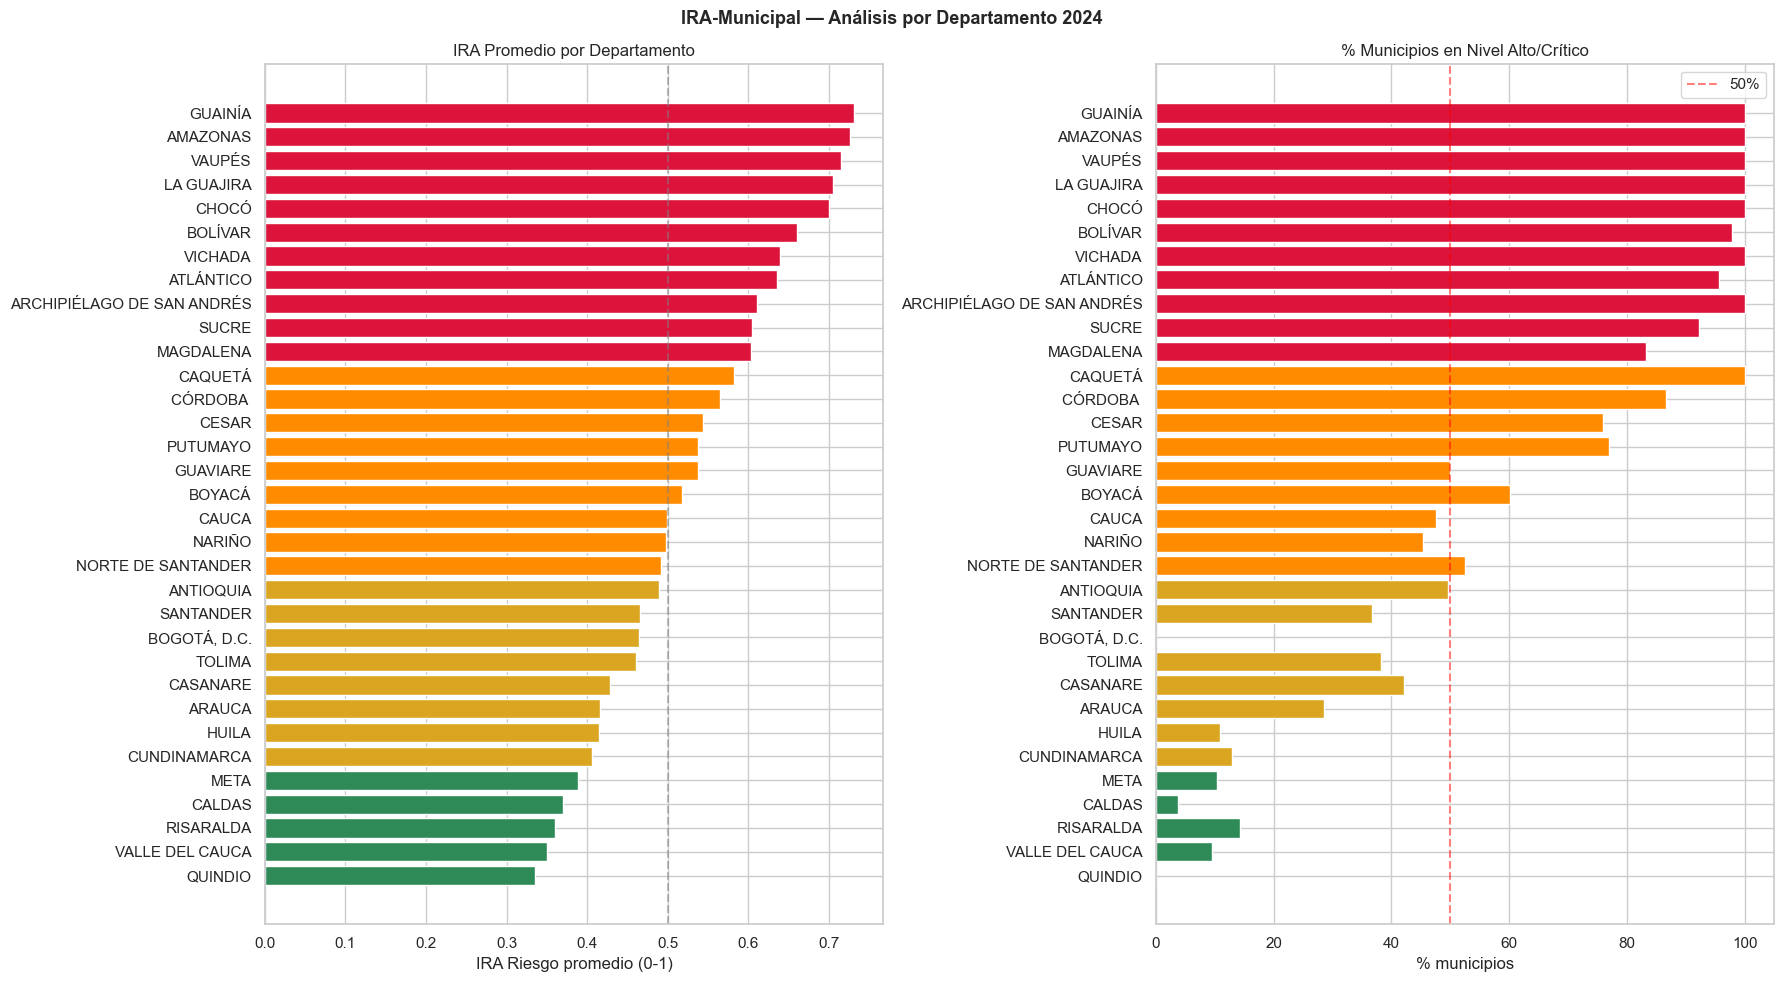

💾 Guardado: reports/figures/reporte_departamentos.png


In [3]:
print('='*60)
print('REPORTE 2 — Análisis por Departamento')
print('='*60)

# Agregar departamento
df_ira['cod_depto']    = df_ira['divipola'].str[:2]
df_master['cod_depto'] = df_master['divipola'].str[:2]

# Cargar nombres de departamentos desde NBI
df_nbi = pd.read_parquet('../data/02_intermediate/nbi_limpia.parquet')
df_nbi['cod_depto'] = df_nbi['divipola'].str[:2]
dept_nombres = df_nbi.groupby('cod_depto')['nombre_depto'].first().reset_index()

df_ira_dept = df_ira.merge(dept_nombres, on='cod_depto', how='left')

# Estadísticas por departamento
dept_stats = df_ira_dept.groupby('nombre_depto').agg(
    n_municipios      = ('divipola',    'count'),
    ira_promedio      = ('ira_riesgo',  'mean'),
    n_criticos        = ('nivel_ira',   lambda x: (x=='Crítico').sum()),
    n_alto            = ('nivel_ira',   lambda x: (x=='Alto').sum()),
    pct_critico_alto  = ('nivel_ira',   lambda x: ((x.isin(['Crítico','Alto'])).sum()/len(x)*100)),
).reset_index().sort_values('ira_promedio', ascending=False)

print(f'Top 10 departamentos con mayor IRA promedio:')
print(dept_stats.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.suptitle('IRA-Municipal — Análisis por Departamento 2024',
             fontsize=13, fontweight='bold')

# IRA promedio por departamento
colores_dept = ['crimson' if v > 0.59 else 'darkorange' if v > 0.49
                else 'goldenrod' if v > 0.40 else 'seagreen'
                for v in dept_stats['ira_promedio']]
axes[0].barh(dept_stats['nombre_depto'][::-1],
             dept_stats['ira_promedio'][::-1],
             color=colores_dept[::-1], edgecolor='white')
axes[0].set_title('IRA Promedio por Departamento')
axes[0].set_xlabel('IRA Riesgo promedio (0-1)')
axes[0].axvline(0.5, color='gray', linestyle='--', alpha=0.5)

# % municipios Alto/Crítico
axes[1].barh(dept_stats['nombre_depto'][::-1],
             dept_stats['pct_critico_alto'][::-1],
             color=colores_dept[::-1], edgecolor='white')
axes[1].set_title('% Municipios en Nivel Alto/Crítico')
axes[1].set_xlabel('% municipios')
axes[1].axvline(50, color='red', linestyle='--', alpha=0.5, label='50%')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / 'reporte_departamentos.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado: reports/figures/reporte_departamentos.png')

In [4]:
print('='*60)
print('REPORTE 3 — Exportar Dataset IRA para datos.gov.co')
print('='*60)

# Dataset limpio para publicación
cols_publicar = [
    'divipola','municipio',
    'ira_riesgo','nivel_ira',
    'score_D1','score_D2','score_D3','score_D4',
    'prob_critico','prob_riesgo_severo',
    'nivel_predicho',
    'cultivo_top1','cultivo_top2','cultivo_top3',
    'cultivo_top4','cultivo_top5',
]
cols_disponibles = [c for c in cols_publicar if c in df_ira.columns]
df_publicar = df_ira[cols_disponibles].copy()

# Renombrar para claridad
df_publicar = df_publicar.rename(columns={
    'divipola':           'codigo_municipio_divipola',
    'municipio':          'nombre_municipio',
    'ira_riesgo':         'ira_score_riesgo',
    'nivel_ira':          'ira_nivel',
    'score_D1':           'score_dimension_produccion',
    'score_D2':           'score_dimension_acceso',
    'score_D3':           'score_dimension_clima',
    'score_D4':           'score_dimension_socioeconomico',
    'prob_critico':       'probabilidad_nivel_critico',
    'prob_riesgo_severo': 'probabilidad_riesgo_severo',
    'nivel_predicho':     'nivel_predicho_xgboost',
})

# Agregar metadatos
df_publicar['fecha_calculo']   = datetime.now().strftime('%Y-%m-%d')
df_publicar['version_ira']     = '1.0'
df_publicar['fuente']          = 'IRA-Municipal — Datos al Ecosistema 2026'
df_publicar['ano_base_datos']  = 2024

# Guardar CSV
ruta_csv = REPORTS / 'ira_municipal_2024.csv'
df_publicar.to_csv(ruta_csv, index=False, encoding='utf-8-sig')

print(f'✅ Dataset para publicación:')
print(f'   Municipios: {len(df_publicar):,}')
print(f'   Columnas: {len(df_publicar.columns):,}')
print(f'   Archivo: {ruta_csv}')
print(f'\nPrimeras filas:')
print(df_publicar.head(3).to_string())

# También exportar timeline completo
ruta_timeline = REPORTS / 'ira_timeline_2021_2029.csv'
df_timeline.to_csv(ruta_timeline, index=False, encoding='utf-8-sig')
print(f'\n✅ Timeline exportado: {ruta_timeline}')
print(f'   {len(df_timeline):,} registros (2021-2029, 4 escenarios)')

REPORTE 3 — Exportar Dataset IRA para datos.gov.co
✅ Dataset para publicación:
   Municipios: 1,122
   Columnas: 20
   Archivo: ..\reports\ira_municipal_2024.csv

Primeras filas:
  codigo_municipio_divipola nombre_municipio  ira_score_riesgo ira_nivel  score_dimension_produccion  score_dimension_acceso  score_dimension_clima  score_dimension_socioeconomico  probabilidad_nivel_critico  probabilidad_riesgo_severo nivel_predicho_xgboost cultivo_top1 cultivo_top2     cultivo_top3      cultivo_top4 cultivo_top5 fecha_calculo version_ira                                    fuente  ano_base_datos
0                     05001         MEDELLÍN              0.27      Bajo                        0.63                    0.95                   0.49                            0.73                        0.00                        0.00                   Bajo         Caña      Plátano  Cebolla de rama              Mora         Papa    2026-07-23         1.0  IRA-Municipal — Datos al Ecosistema 2026    

REPORTE 4 — Resumen Final del Proyecto


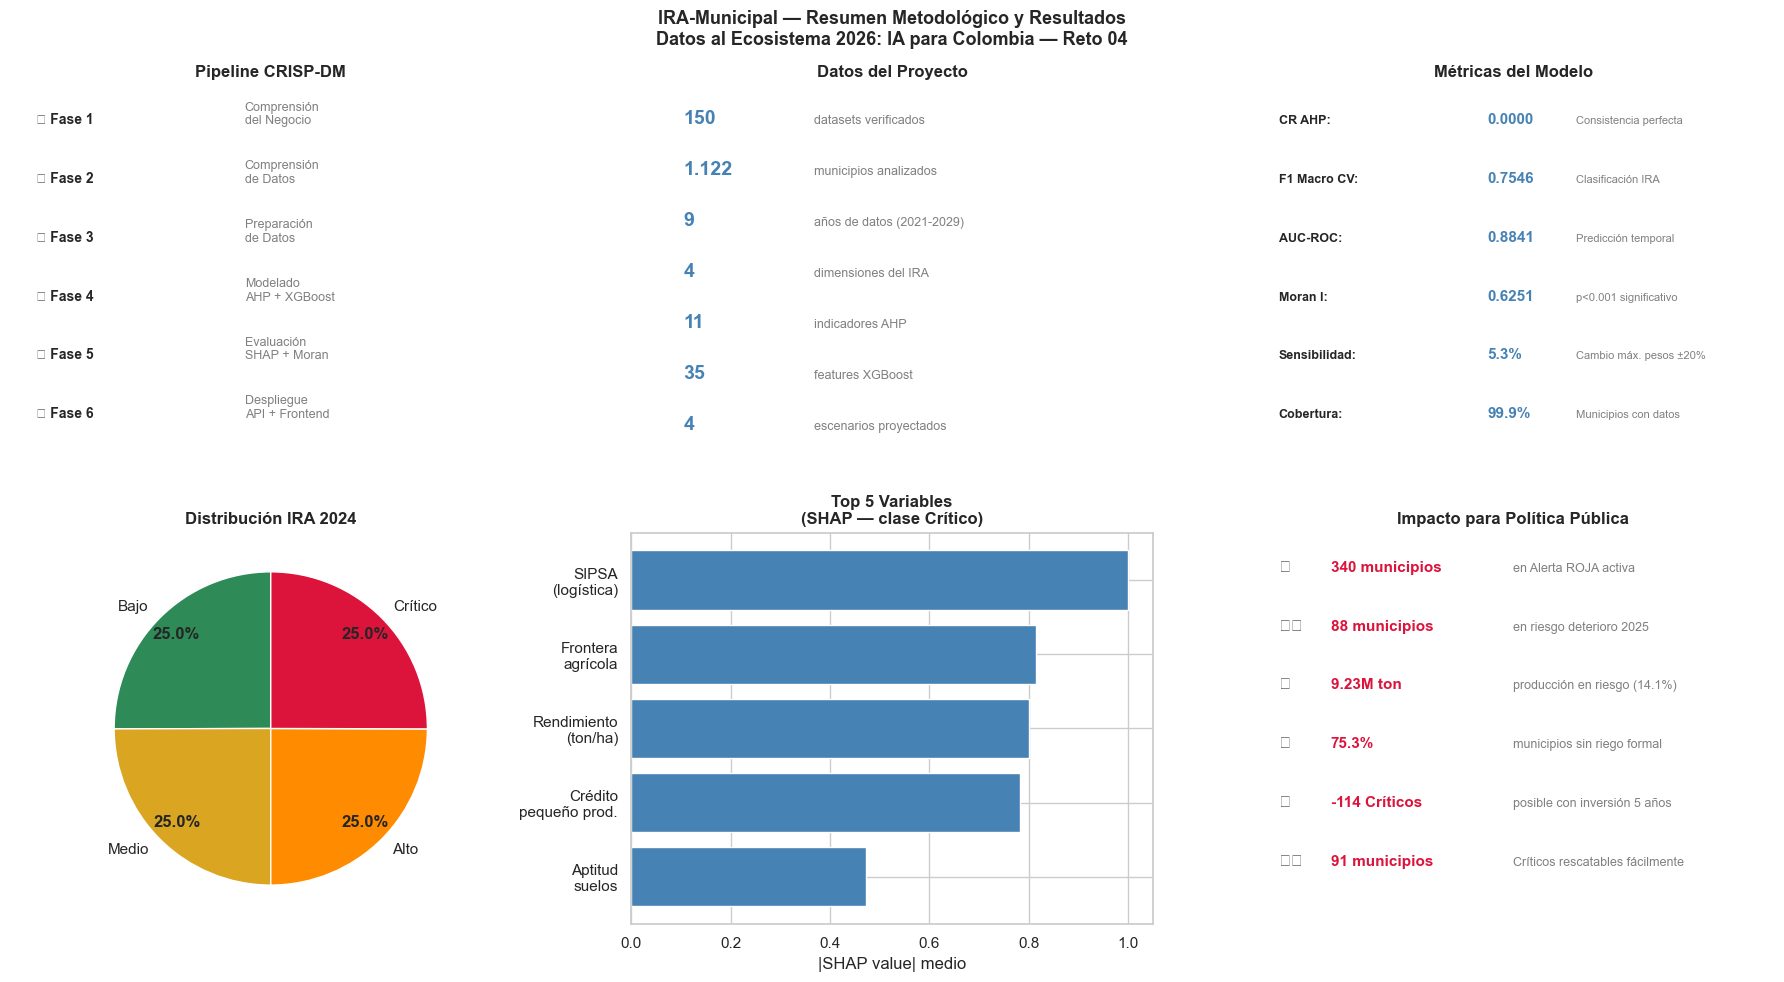

💾 Guardado: reports/figures/reporte_resumen_proyecto.png


In [5]:
print('='*60)
print('REPORTE 4 — Resumen Final del Proyecto')
print('='*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('IRA-Municipal — Resumen Metodológico y Resultados\n'
             'Datos al Ecosistema 2026: IA para Colombia — Reto 04',
             fontsize=13, fontweight='bold')

# ─── Pipeline CRISP-DM ───────────────────────────────────────────────────────
ax = axes[0,0]
ax.axis('off')
fases = [
    ('Fase 1', 'Comprensión\ndel Negocio', '✅'),
    ('Fase 2', 'Comprensión\nde Datos', '✅'),
    ('Fase 3', 'Preparación\nde Datos', '✅'),
    ('Fase 4', 'Modelado\nAHP + XGBoost', '✅'),
    ('Fase 5', 'Evaluación\nSHAP + Moran', '✅'),
    ('Fase 6', 'Despliegue\nAPI + Frontend', '✅'),
]
for i, (fase, desc, estado) in enumerate(fases):
    y = 0.9 - i * 0.15
    ax.text(0.05, y, f'{estado} {fase}', fontsize=10,
            fontweight='bold', transform=ax.transAxes)
    ax.text(0.45, y, desc, fontsize=9,
            color='gray', transform=ax.transAxes)
ax.set_title('Pipeline CRISP-DM', fontweight='bold')

# ─── Datos utilizados ─────────────────────────────────────────────────────────
ax = axes[0,1]
ax.axis('off')
datos = [
    ('150', 'datasets verificados'),
    ('1.122', 'municipios analizados'),
    ('9', 'años de datos (2021-2029)'),
    ('4', 'dimensiones del IRA'),
    ('11', 'indicadores AHP'),
    ('35', 'features XGBoost'),
    ('4', 'escenarios proyectados'),
]
for i, (num, desc) in enumerate(datos):
    y = 0.9 - i * 0.13
    ax.text(0.1, y, num, fontsize=14, fontweight='bold',
            color='steelblue', transform=ax.transAxes)
    ax.text(0.35, y, desc, fontsize=9,
            color='gray', transform=ax.transAxes)
ax.set_title('Datos del Proyecto', fontweight='bold')

# ─── Métricas del modelo ─────────────────────────────────────────────────────
ax = axes[0,2]
ax.axis('off')
metricas_modelo = [
    ('CR AHP',          '0.0000', 'Consistencia perfecta'),
    ('F1 Macro CV',     '0.7546', 'Clasificación IRA'),
    ('AUC-ROC',         '0.8841', 'Predicción temporal'),
    ('Moran I',         '0.6251', 'p<0.001 significativo'),
    ('Sensibilidad',    '5.3%',   'Cambio máx. pesos ±20%'),
    ('Cobertura',       '99.9%',  'Municipios con datos'),
]
for i, (metrica, valor, desc) in enumerate(metricas_modelo):
    y = 0.9 - i * 0.15
    ax.text(0.05, y, f'{metrica}:', fontsize=9,
            fontweight='bold', transform=ax.transAxes)
    ax.text(0.45, y, valor, fontsize=11,
            fontweight='bold', color='steelblue',
            transform=ax.transAxes)
    ax.text(0.62, y, desc, fontsize=8,
            color='gray', transform=ax.transAxes)
ax.set_title('Métricas del Modelo', fontweight='bold')

# ─── Distribución IRA final ───────────────────────────────────────────────────
ax = axes[1,0]
niveles = ['Bajo','Medio','Alto','Crítico']
conteos = [dist_nivel.get(n, 0) for n in niveles]
colores = ['seagreen','goldenrod','darkorange','crimson']
wedges, texts, autotexts = ax.pie(
    conteos, labels=niveles, colors=colores,
    autopct='%1.1f%%', startangle=90,
    pctdistance=0.85
)
for text in autotexts:
    text.set_fontweight('bold')
ax.set_title('Distribución IRA 2024', fontweight='bold')

# ─── SHAP top 5 ───────────────────────────────────────────────────────────────
ax = axes[1,1]
shap_top5 = pd.DataFrame({
    'feature': ['SIPSA\n(logística)', 'Frontera\nagrícola',
                'Rendimiento\n(ton/ha)', 'Crédito\npequeño prod.',
                'Aptitud\nsuelos'],
    'shap':    [0.9995, 0.8153, 0.8014, 0.7815, 0.4734]
})
ax.barh(shap_top5['feature'][::-1], shap_top5['shap'][::-1],
        color='steelblue', edgecolor='white')
ax.set_title('Top 5 Variables\n(SHAP — clase Crítico)', fontweight='bold')
ax.set_xlabel('|SHAP value| medio')

# ─── Impacto política pública ────────────────────────────────────────────────
ax = axes[1,2]
ax.axis('off')
impactos = [
    ('🔴', '340 municipios', 'en Alerta ROJA activa'),
    ('⚠️', '88 municipios',  'en riesgo deterioro 2025'),
    ('🌾', '9.23M ton',      'producción en riesgo (14.1%)'),
    ('💧', '75.3%',          'municipios sin riego formal'),
    ('📉', '-114 Críticos',  'posible con inversión 5 años'),
    ('🏘️', '91 municipios',  'Críticos rescatables fácilmente'),
]
for i, (emoji, valor, desc) in enumerate(impactos):
    y = 0.9 - i * 0.15
    ax.text(0.05, y, emoji, fontsize=12, transform=ax.transAxes)
    ax.text(0.15, y, valor, fontsize=11, fontweight='bold',
            color='crimson', transform=ax.transAxes)
    ax.text(0.50, y, desc, fontsize=9,
            color='gray', transform=ax.transAxes)
ax.set_title('Impacto para Política Pública', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES / 'reporte_resumen_proyecto.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado: reports/figures/reporte_resumen_proyecto.png')

In [6]:
print('='*60)
print('RESUMEN FINAL — Notebook 05 Completado')
print('='*60)

archivos_report = list(REPORTS.glob('*.csv')) + list(FIGURES.glob('*.png'))
print(f'\nArchivos generados en reports/:')
for f in sorted(archivos_report):
    mb = f.stat().st_size / (1024*1024)
    print(f'  ✅ {f.name} ({mb:.1f} MB)')

print(f'\n{"="*60}')
print(f'PROYECTO IRA-MUNICIPAL — COMPLETADO')
print(f'{"="*60}')
print(f'''
Pipeline CRISP-DM:
  ✅ Notebook 00 — Comprensión del negocio
  ✅ Notebook 01 — EDA y exploración de datos
  ✅ Notebook 02 — Limpieza y transformación
  ✅ Notebook 03 — Análisis descriptivo y features
  ✅ Notebook 04 — Modelo predictivo AHP + XGBoost
  ✅ Notebook 05 — Reportes automáticos

Resultados clave:
  • IRA calculado para 1.122 municipios de Colombia
  • CR AHP = 0.0000 (consistencia perfecta)
  • F1 Macro CV = 0.7546 (clasificación multiclase)
  • AUC-ROC = 0.8841 (predicción temporal)
  • Moran I = 0.6251 (p<0.001, clustering espacial)
  • 340 municipios en Alerta ROJA con El Niño activo
  • Proyección 2025-2029 bajo 3 escenarios

Datos publicados:
  • ira_municipal_2024.csv — dataset para datos.gov.co
  • ira_timeline_2021_2029.csv — serie histórica + proyección

Competencia:
  • Datos al Ecosistema 2026: IA para Colombia
  • Reto 04 — Agricultura y Desarrollo Rural
  • Equipo: 3 integrantes
''')

print(f'Fecha de generación: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

RESUMEN FINAL — Notebook 05 Completado

Archivos generados en reports/:
  ✅ analisis_departamentos.png (0.2 MB)
  ✅ analisis_gaps.png (0.1 MB)
  ✅ aptitud_transformacion_log.png (0.2 MB)
  ✅ correlaciones.png (0.2 MB)
  ✅ cultivos_en_riesgo.png (0.2 MB)
  ✅ feat_aptitud.png (0.1 MB)
  ✅ feat_clima.png (0.0 MB)
  ✅ feat_clima_knn.png (0.1 MB)
  ✅ feat_eva.png (0.1 MB)
  ✅ feat_finagro.png (0.1 MB)
  ✅ feat_frontera.png (0.1 MB)
  ✅ feat_riego.png (0.1 MB)
  ✅ feat_sipsa_a.png (0.1 MB)
  ✅ feat_socioeconomico.png (0.2 MB)
  ✅ ira_ahp_resultados.png (0.2 MB)
  ✅ ira_niveles.png (0.1 MB)
  ✅ ira_por_anio_escenario.png (0.1 MB)
  ✅ moran_espacial.png (0.2 MB)
  ✅ municipios_frontera.png (0.2 MB)
  ✅ normalizacion.png (0.1 MB)
  ✅ radar_municipios.png (0.2 MB)
  ✅ rank_normalization.png (0.2 MB)
  ✅ reporte_departamentos.png (0.2 MB)
  ✅ reporte_ejecutivo_nacional.png (0.3 MB)
  ✅ reporte_resumen_proyecto.png (0.3 MB)
  ✅ scatter_matrix.png (0.5 MB)
  ✅ scores_dimensiones_final.png (0.1 MB)
